# CICIDS2017 — RF + XGBoost Ensemble Training
### 46 features, 5 classes: Normal Traffic, DoS, DDoS, Brute Force, Port Scan
Run on Kaggle with `cicids2017_preprocessed.csv` uploaded as a dataset.

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import RobustScaler
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

# Paths — update if running locally
DATA_PATH   = r'D:\Academic\ML\ModelTraining\Preprocessing\cicids2017_preprocessed.csv'
MODEL_OUT   = r'D:\Academic\ML\ModelTraining\newOutput\ensemble_model.pkl'
SCALER_OUT  = r'D:\Academic\ML\ModelTraining\newOutput\scaler.pkl'
ENCODER_OUT = r'D:\Academic\ML\ModelTraining\newOutput\label_encoder.pkl'

RANDOM_STATE = 42

## 1. Load Data

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'\nClass distribution:')
print(df['Attack Type'].value_counts())
print(f'\nFeatures: {df.shape[1] - 1}')

Shape: (2515963, 47)

Class distribution:
Attack Type
Normal Traffic    2094458
DoS                193647
DDoS               128014
Port Scan           90694
Brute Force          9150
Name: count, dtype: int64

Features: 46


## 2. Feature / Label Split

In [3]:
feature_cols = [c for c in df.columns if c != 'Attack Type']
print(f'Feature columns ({len(feature_cols)}):')
for i, c in enumerate(feature_cols):
    print(f'  {i+1:2d}. {c}')

X = df[feature_cols].values
y_raw = df['Attack Type'].values

Feature columns (46):
   1. Destination Port
   2. Flow Duration
   3. Total Fwd Packets
   4. Total Backward Packets
   5. Total Length of Fwd Packets
   6. Total Length of Bwd Packets
   7. Fwd Packet Length Max
   8. Fwd Packet Length Min
   9. Fwd Packet Length Mean
  10. Fwd Packet Length Std
  11. Bwd Packet Length Max
  12. Bwd Packet Length Min
  13. Bwd Packet Length Mean
  14. Bwd Packet Length Std
  15. Flow Bytes/s
  16. Flow Packets/s
  17. Flow IAT Mean
  18. Flow IAT Std
  19. Flow IAT Max
  20. Flow IAT Min
  21. Fwd IAT Mean
  22. Fwd IAT Std
  23. Fwd IAT Min
  24. Bwd IAT Total
  25. Bwd IAT Mean
  26. Bwd IAT Max
  27. Bwd IAT Min
  28. Fwd Header Length
  29. Bwd Header Length
  30. Bwd Packets/s
  31. Min Packet Length
  32. Max Packet Length
  33. Packet Length Mean
  34. Packet Length Std
  35. Packet Length Variance
  36. FIN Flag Count
  37. PSH Flag Count
  38. ACK Flag Count
  39. Init_Win_bytes_forward
  40. Init_Win_bytes_backward
  41. act_data_pkt_fwd
  

## 3. Label Encoding

In [4]:
le = LabelEncoder()
y = le.fit_transform(y_raw)
print(f'Classes: {list(le.classes_)}')
print(f'Encoded: {list(range(len(le.classes_)))}')

joblib.dump(le, ENCODER_OUT)
print(f'Saved: {ENCODER_OUT}')

Classes: ['Brute Force', 'DDoS', 'DoS', 'Normal Traffic', 'Port Scan']
Encoded: [0, 1, 2, 3, 4]
Saved: D:\Academic\ML\ModelTraining\newOutput\label_encoder.pkl


## 4. Train / Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

# Verify stratification
unique, counts = np.unique(y_train, return_counts=True)
print('\nTrain class distribution:')
for cls, cnt in zip(le.classes_, counts):
    print(f'  {cls}: {cnt:,}')

Train: (2012770, 46), Test: (503193, 46)

Train class distribution:
  Brute Force: 7,320
  DDoS: 102,411
  DoS: 154,918
  Normal Traffic: 1,675,566
  Port Scan: 72,555


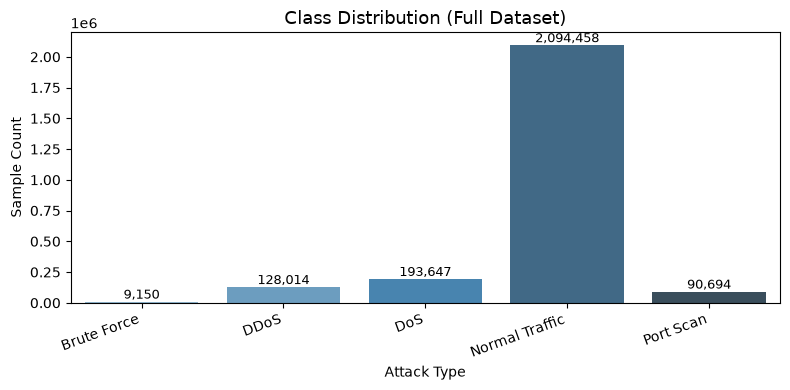

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
class_counts = pd.Series(
    [(y_train == i).sum() + (y_test == i).sum() for i in range(len(le.classes_))],
    index=le.classes_
)
sns.barplot(x=class_counts.index, y=class_counts.values, palette='Blues_d', ax=ax)
ax.set_title('Class Distribution (Full Dataset)', fontsize=13)
ax.set_xlabel('Attack Type')
ax.set_ylabel('Sample Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(r'D:\Academic\ML\ModelTraining\newOutput\class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Scaling

In [7]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

joblib.dump(scaler, SCALER_OUT)
print(f'Saved: {SCALER_OUT}')

Saved: D:\Academic\ML\ModelTraining\newOutput\scaler.pkl


## 6. Compute Sample Weights
Handles class imbalance for both RF and XGBoost.

In [8]:
# sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
# print(f'Sample weight range: {sample_weights.min():.4f} — {sample_weights.max():.4f}')

# # Show effective weight per class
# for cls_idx, cls_name in enumerate(le.classes_):
#     mask = y_train == cls_idx
#     print(f'  {cls_name}: weight = {sample_weights[mask].mean():.4f}')

In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight

# 1. Compute original balanced weights per class index
classes = np.unique(y_train)
balanced_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)

# 2. Map class index to its newly adjusted weight
# Example adjustments: Normal Traffic x 0.8 (decrease), all attack classes x 1.25 (increase)
manual_class_weights = {}
for cls_idx, cls_name in enumerate(le.classes_):
    if cls_name == 'Normal Traffic':
        manual_class_weights[cls_idx] = balanced_weights[cls_idx] * 0.8
    elif cls_name == 'Brute Force':
        manual_class_weights[cls_idx] = balanced_weights[cls_idx] * 3.0  # highest boost
    elif cls_name == 'DoS' or cls_name == 'DDoS':
        manual_class_weights[cls_idx] = balanced_weights[cls_idx] * 1.5  # these overlap, moderate boost
    else:
        manual_class_weights[cls_idx] = balanced_weights[cls_idx] * 1.5
# 3. Compute final sample weights using your modified class weights
sample_weights = compute_sample_weight(class_weight=manual_class_weights, y=y_train)

# 4. Print results to verify
print(f'Sample weight range: {sample_weights.min():.4f} — {sample_weights.max():.4f}')
for cls_idx, cls_name in enumerate(le.classes_):
    mask = y_train == cls_idx
    print(f'  {cls_name}: weight = {sample_weights[mask].mean():.4f}')

Sample weight range: 0.1922 — 164.9811
  Brute Force: weight = 164.9811
  DDoS: weight = 5.8962
  DoS: weight = 3.8977
  Normal Traffic: weight = 0.1922
  Port Scan: weight = 8.3224


## 7. Train Random Forest

In [10]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    max_features='sqrt',
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rf.fit(X_train_scaled, y_train,sample_weight=sample_weights)
print('RF training complete.')

rf_train_acc = rf.score(X_train_scaled, y_train)
rf_test_acc  = rf.score(X_test_scaled,  y_test)
print(f'RF Train Accuracy: {rf_train_acc:.4f}')
print(f'RF Test  Accuracy: {rf_test_acc:.4f}')

RF training complete.
RF Train Accuracy: 0.9995
RF Test  Accuracy: 0.9994


## 8. Train XGBoost
Trained separately with sample_weight — fixes the VotingClassifier bug
where sample weights are not routed to internal estimators.

In [11]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.5,
    tree_method='hist',
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    n_jobs=1
)
# Pass sample_weight directly — this is the fix for the imbalance bug
xgb.fit(X_train_scaled, y_train, sample_weight=sample_weights,
        eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
        verbose=20)
print('XGBoost training complete.')

xgb_train_acc = xgb.score(X_train_scaled, y_train)
xgb_test_acc  = xgb.score(X_test_scaled,  y_test)
print(f'XGB Train Accuracy: {xgb_train_acc:.4f}')
print(f'XGB Test  Accuracy: {xgb_test_acc:.4f}')

[0]	validation_0-mlogloss:1.81903	validation_1-mlogloss:1.81914
[20]	validation_0-mlogloss:0.22753	validation_1-mlogloss:0.22759
[40]	validation_0-mlogloss:0.04448	validation_1-mlogloss:0.04452
[60]	validation_0-mlogloss:0.01319	validation_1-mlogloss:0.01330
[80]	validation_0-mlogloss:0.00609	validation_1-mlogloss:0.00622
[100]	validation_0-mlogloss:0.00399	validation_1-mlogloss:0.00411
[120]	validation_0-mlogloss:0.00304	validation_1-mlogloss:0.00317
[140]	validation_0-mlogloss:0.00262	validation_1-mlogloss:0.00276
[160]	validation_0-mlogloss:0.00236	validation_1-mlogloss:0.00252
[180]	validation_0-mlogloss:0.00220	validation_1-mlogloss:0.00237
[199]	validation_0-mlogloss:0.00209	validation_1-mlogloss:0.00227
XGBoost training complete.
XGB Train Accuracy: 0.9996
XGB Test  Accuracy: 0.9996


## 9. Build Soft-Voting Ensemble
Uses pre-fitted estimators — VotingClassifier is set to use them as-is.

In [12]:
from sklearn.preprocessing import LabelEncoder as SklearnLE
from sklearn.utils.multiclass import unique_labels

# Manually construct a minimal internal LabelEncoder that maps 0-4 to 0-4
internal_le = SklearnLE()
internal_le.fit(np.array(list(range(len(le.classes_)))))

ensemble = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb)],
    voting='soft'
)
ensemble.estimators_ = [rf, xgb]
ensemble.le_ = internal_le
ensemble.classes_ = np.array(list(range(len(le.classes_))))
ensemble.named_estimators_ = {'rf': rf, 'xgb': xgb}

ensemble_test_acc = ensemble.score(X_test_scaled, y_test)
print(f'Ensemble Test Accuracy: {ensemble_test_acc:.4f}')

joblib.dump(ensemble, MODEL_OUT)
print(f'Saved: {MODEL_OUT}')

Ensemble Test Accuracy: 0.9996
Saved: D:\Academic\ML\ModelTraining\newOutput\ensemble_model.pkl


## 10. Classification Report

In [13]:
y_pred = ensemble.predict(X_test_scaled)
print(classification_report(y_test, y_pred, target_names=le.classes_, digits=4))

                precision    recall  f1-score   support

   Brute Force     0.9995    0.9995    0.9995      1830
          DDoS     0.9997    1.0000    0.9998     25603
           DoS     0.9975    0.9999    0.9987     38729
Normal Traffic     1.0000    0.9996    0.9998    418892
     Port Scan     0.9954    0.9994    0.9974     18139

      accuracy                         0.9996    503193
     macro avg     0.9984    0.9997    0.9990    503193
  weighted avg     0.9996    0.9996    0.9996    503193



In [14]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
print("\nRow = True, Col = Predicted")
print(cm_df)
# DoS-DDoS off-diagonal specifically
dos_idx = list(le.classes_).index('DoS')
ddos_idx = list(le.classes_).index('DDoS')
print(f"\nDoS predicted as DDoS: {cm[dos_idx][ddos_idx]}")
print(f"DDoS predicted as DoS: {cm[ddos_idx][dos_idx]}")


Row = True, Col = Predicted
                Brute Force   DDoS    DoS  Normal Traffic  Port Scan
Brute Force            1829      0      0               1          0
DDoS                      0  25603      0               0          0
DoS                       0      0  38727               2          0
Normal Traffic            1      8     92          418707         84
Port Scan                 0      0      7               3      18129

DoS predicted as DDoS: 0
DDoS predicted as DoS: 0


## 11. Confusion Matrix

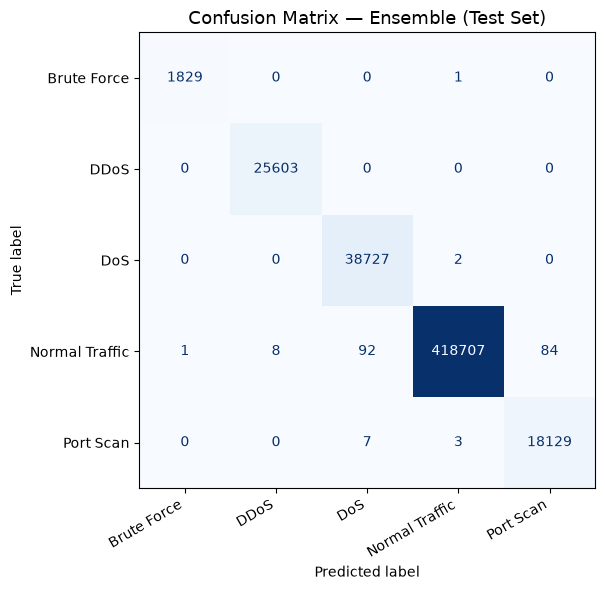

In [15]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Ensemble (Test Set)', fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(r'D:\Academic\ML\ModelTraining\newOutput\confusion_matrix.png', bbox_inches='tight')
plt.show()

## 12. Per-Model Comparison

In [16]:
from sklearn.metrics import f1_score

rf_pred  = rf.predict(X_test_scaled)
xgb_pred = xgb.predict(X_test_scaled)
ens_pred = y_pred

results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'Ensemble'],
    'Test Accuracy': [
        rf.score(X_test_scaled, y_test),
        xgb.score(X_test_scaled, y_test),
        ensemble.score(X_test_scaled, y_test)
    ],
    'Macro F1': [
        f1_score(y_test, rf_pred,  average='macro'),
        f1_score(y_test, xgb_pred, average='macro'),
        f1_score(y_test, ens_pred, average='macro')
    ],
    'Weighted F1': [
        f1_score(y_test, rf_pred,  average='weighted'),
        f1_score(y_test, xgb_pred, average='weighted'),
        f1_score(y_test, ens_pred, average='weighted')
    ]
})
print(results.to_string(index=False))

        Model  Test Accuracy  Macro F1  Weighted F1
Random Forest       0.999448  0.998794     0.999448
      XGBoost       0.999601  0.999028     0.999601
     Ensemble       0.999607  0.999036     0.999607


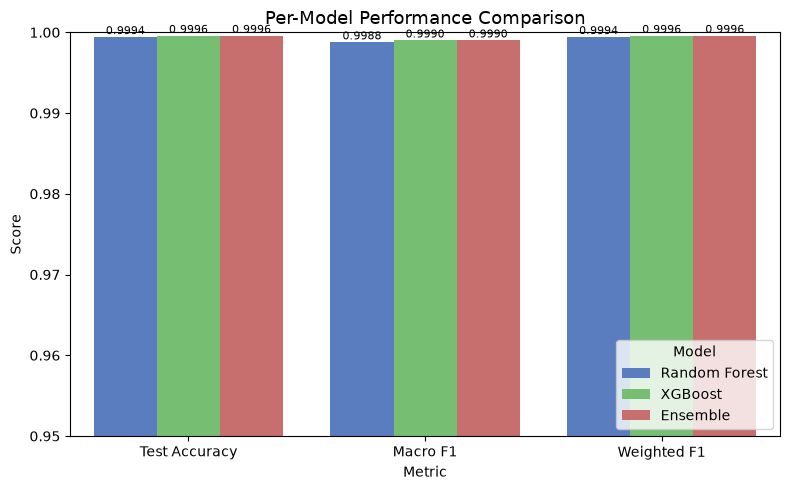

In [17]:
metrics_df = results.melt(id_vars='Model', value_vars=['Test Accuracy', 'Macro F1', 'Weighted F1'],
                           var_name='Metric', value_name='Score')
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=metrics_df, x='Metric', y='Score', hue='Model',
            palette=['#4878CF', '#6ACC65', '#D65F5F'], ax=ax)
ax.set_title('Per-Model Performance Comparison', fontsize=13)
ax.set_ylabel('Score')
ax.set_ylim(0.95, 1.0)
ax.legend(title='Model', loc='lower right')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(r'D:\Academic\ML\ModelTraining\newOutput\model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

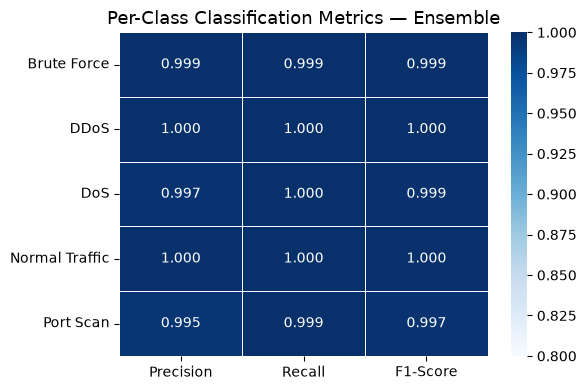

In [18]:
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
report_df = pd.DataFrame(report).T.loc[le.classes_, ['precision', 'recall', 'f1-score']]

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(report_df.astype(float), annot=True, fmt='.3f', cmap='Blues',
            linewidths=0.5, ax=ax, vmin=0.8, vmax=1.0)
ax.set_title('Per-Class Classification Metrics — Ensemble', fontsize=13)
ax.set_xticklabels(['Precision', 'Recall', 'F1-Score'])
plt.tight_layout()
plt.savefig(r'D:\Academic\ML\ModelTraining\newOutput\classification_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 13. Feature Importance (RF)

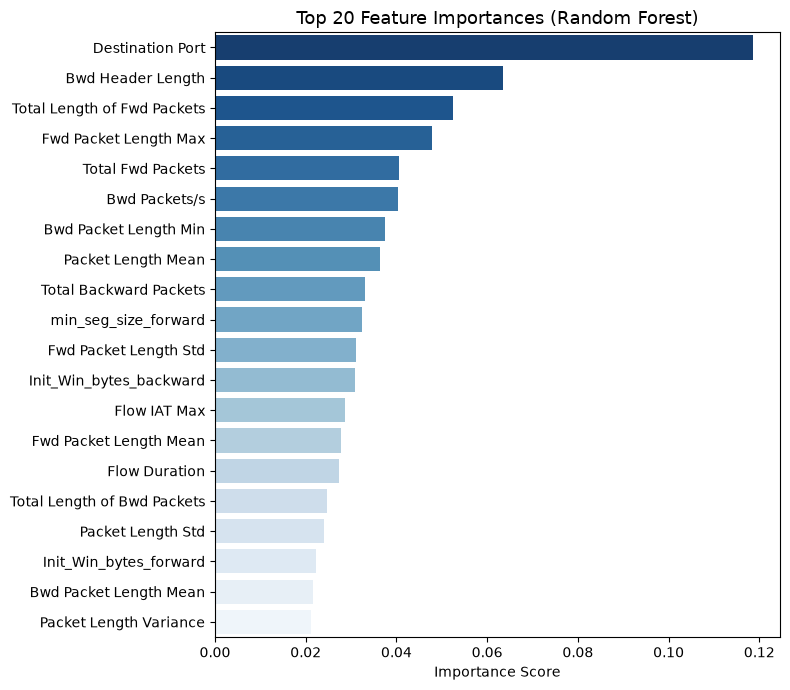

In [19]:
top_n = 20
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
top_features = importances.head(top_n)

fig, ax = plt.subplots(figsize=(8, 7))
sns.barplot(x=top_features.values, y=top_features.index, palette='Blues_r', ax=ax)
ax.set_title(f'Top {top_n} Feature Importances (Random Forest)', fontsize=13)
ax.set_xlabel('Importance Score')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(r'D:\Academic\ML\ModelTraining\newOutput\feature_importance_top20.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
anova_top10 = [
    'Fwd Packet Length Max', 'Fwd Packet Length Std', 'Bwd Header Length',
    'Fwd Header Length', 'Idle Mean', 'Total Fwd Packets',
    'Flow IAT Max', 'Flow Duration', 'Fwd IAT Std', 'Total Backward Packets'
]
top_n = importances.head(20).index.tolist()
overlap = [f for f in anova_top10 if f in top_n]
print(f"ANOVA top-10 features also in RF top-20: {len(overlap)}/10")
print(overlap)

ANOVA top-10 features also in RF top-20: 7/10
['Fwd Packet Length Max', 'Fwd Packet Length Std', 'Bwd Header Length', 'Total Fwd Packets', 'Flow IAT Max', 'Flow Duration', 'Total Backward Packets']


## 14. Verify Saved Artifacts

In [22]:
# Reload and do a quick sanity check
loaded_model   = joblib.load(MODEL_OUT)
loaded_scaler  = joblib.load(SCALER_OUT)
loaded_encoder = joblib.load(ENCODER_OUT)

# Single sample prediction
sample_raw     = X_test[0:1]
sample_scaled  = loaded_scaler.transform(sample_raw)
pred_encoded   = loaded_model.predict(sample_scaled)
pred_label     = loaded_encoder.inverse_transform(pred_encoded)
pred_proba     = loaded_model.predict_proba(sample_scaled)

print(f'Sample prediction: {pred_label[0]}')
print(f'True label:        {loaded_encoder.inverse_transform([y_test[0]])[0]}')
print(f'\nClass probabilities:')
for cls, prob in zip(loaded_encoder.classes_, pred_proba[0]):
    print(f'  {cls}: {prob:.4f}')

Sample prediction: Normal Traffic
True label:        Normal Traffic

Class probabilities:
  Brute Force: 0.0000
  DDoS: 0.0000
  DoS: 0.0000
  Normal Traffic: 1.0000
  Port Scan: 0.0000
